# Factorial Experimental Designs

## Overview

A factorial design tests multiple factors simultaneously in a single experiment. It is more efficient than running separate A/B tests for each factor and — critically — it detects **interactions**: whether the effect of one factor depends on the level of another.

**Why not run separate A/B tests?**

| Approach | Detects interaction? | Sample efficiency | Tests per factor |
|---|---|---|---|
| Separate A/B tests | ❌ | Poor — n per test | 1 test per factor |
| Full factorial | ✓ | High — shared data | All main effects + interactions |
| Fractional factorial | Partial | Very high | Confounded interactions |

**2×2 factorial structure:**

| | Factor B: Low | Factor B: High |
|---|---|---|
| **Factor A: Low** | Cell (1,1) | Cell (1,2) |
| **Factor A: High** | Cell (2,1) | Cell (2,2) |

Main effect of A = average difference across both levels of B. Interaction A×B = does the effect of A change depending on B's level?

**Key principle:** always test the interaction first. If A×B is significant, main effects cannot be interpreted in isolation — the effect of A depends on the level of B.

---

## Setup

In [1]:
library(tidyverse)
library(ggplot2)
library(broom)
library(emmeans)       # emmeans(), contrast(), interaction_plot()
library(patchwork)

set.seed(42)

# ── 2×2 factorial: two restoration interventions ──────────────────────────────
# Factor A: vegetation planting (absent/present)
# Factor B: flow augmentation (absent/present)
# Outcome: species richness
# True effects: A=+3, B=+2, A×B=+3 (synergistic interaction)

n_per_cell <- 30   # 30 sites per factorial cell

fact_data <- expand_grid(
  planting  = c("absent","present"),
  flow_aug  = c("absent","present")
) %>%
  slice(rep(1:4, each=n_per_cell)) %>%
  mutate(
    A = as.integer(planting=="present"),
    B = as.integer(flow_aug=="present"),
    richness = 18 + 3*A + 2*B + 3*A*B + rnorm(n(), 0, 3)
  )

cat(sprintf("n=%d sites | 2×2 design | %d per cell\n",
            nrow(fact_data), n_per_cell))

# Cell means
cell_means <- fact_data %>%
  group_by(planting, flow_aug) %>%
  summarise(mean=round(mean(richness),2), sd=round(sd(richness),2),
            n=n(), .groups="drop")
print(cell_means)

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'broom' was built under R version 4.4.3"
Warning message:
"package 'emmeans' was built under R version 4.4.

n=120 sites | 2×2 design | 30 per cell
# A tibble: 4 × 5
  planting flow_aug  mean    sd     n
  <chr>    <chr>    <dbl> <dbl> <int>
1 absent   absent    18.2  3.77    30
2 absent   present   19.6  3.15    30
3 present  absent    21.6  2.35    30
4 present  present   25.9  3.09    30


---

## Fitting the Factorial Model

In [2]:
# Full factorial model: main effects + interaction
# Always include the interaction term in a factorial design
lm_full <- lm(richness ~ planting * flow_aug, data=fact_data)
# planting * flow_aug expands to: planting + flow_aug + planting:flow_aug

# Type III ANOVA: tests each effect after accounting for all others
# Use car::Anova(type=3) for unbalanced designs
cat("Type III ANOVA:\n")
print(car::Anova(lm_full, type=3))

cat("\nCoefficients:\n")
print(broom::tidy(lm_full) %>% mutate(across(where(is.numeric), ~round(.x, 3))))

# Interpretation:
# (Intercept): mean when both factors absent
# plantingpresent: effect of planting when flow_aug=absent
# flow_augpresent: effect of flow_aug when planting=absent
# plantingpresent:flow_augpresent: ADDITIONAL effect when BOTH present
# → Do NOT interpret main effects in isolation when interaction is significant

Type III ANOVA:
Anova Table (Type III tests)

Response: richness
                  Sum Sq  Df   F value    Pr(>F)    
(Intercept)       9943.5   1 1014.9329 < 2.2e-16 ***
planting           170.0   1   17.3524 6.001e-05 ***
flow_aug            30.6   1    3.1243   0.07976 .  
planting:flow_aug   64.9   1    6.6289   0.01129 *  
Residuals         1136.5 116                        
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Coefficients:
# A tibble: 4 × 5
  term                            estimate std.error statistic p.value
  <chr>                              <dbl>     <dbl>     <dbl>   <dbl>
1 (Intercept)                        18.2      0.571     31.9    0    
2 plantingpresent                     3.37     0.808      4.17   0    
3 flow_augpresent                     1.43     0.808      1.77   0.08 
4 plantingpresent:flow_augpresent     2.94     1.14       2.58   0.011


---

## Visualising and Interpreting the Interaction

Estimated marginal means:
 planting flow_aug emmean    SE  df lower.CL upper.CL
 absent   absent     18.2 0.571 116     17.1     19.3
 present  absent     21.6 0.571 116     20.4     22.7
 absent   present    19.6 0.571 116     18.5     20.8
 present  present    25.9 0.571 116     24.8     27.1

Confidence level used: 0.95 

Simple effects of planting within each level of flow_aug:
flow_aug = absent:
 contrast         estimate    SE  df t.ratio p.value
 present - absent     3.37 0.808 116   4.166 <0.0001

flow_aug = present:
 contrast         estimate    SE  df t.ratio p.value
 present - absent     6.31 0.808 116   7.807 <0.0001



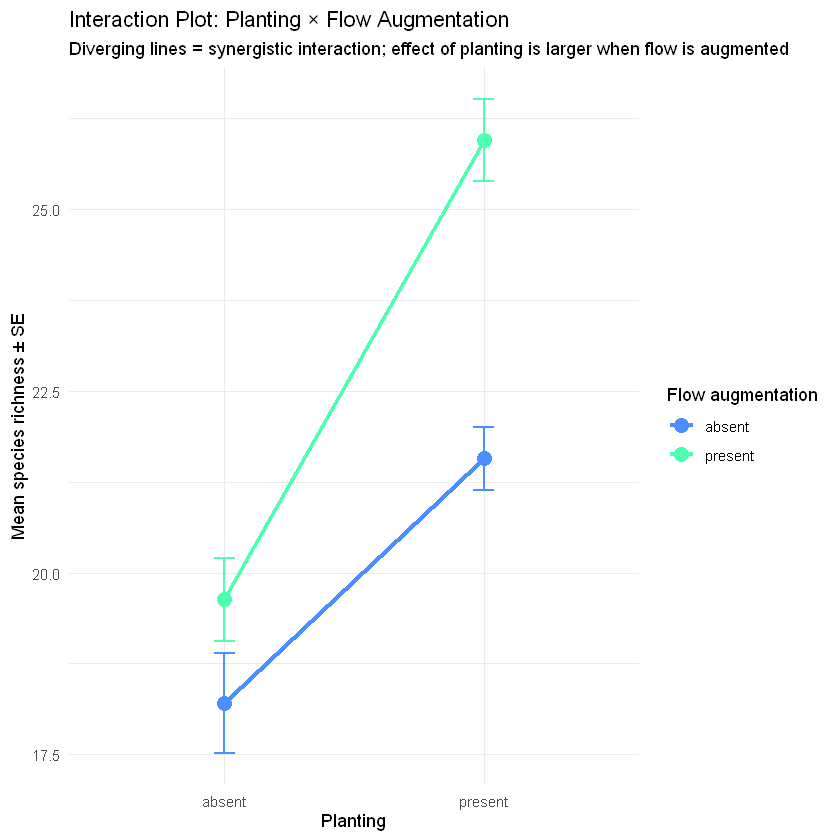

In [3]:
# ── Interaction plot: parallel lines = no interaction; crossing/diverging = interaction ─
p_int <- ggplot(cell_means,
                aes(x=planting, y=mean, color=flow_aug, group=flow_aug)) +
  geom_line(linewidth=1.2) +
  geom_point(size=4) +
  geom_errorbar(aes(ymin=mean-sd/sqrt(n), ymax=mean+sd/sqrt(n)),
                width=0.08, linewidth=0.8) +
  scale_color_manual(values=c(absent="#4a8fff",present="#4fffb0"),
                     name="Flow augmentation") +
  labs(title="Interaction Plot: Planting × Flow Augmentation",
       subtitle="Diverging lines = synergistic interaction; effect of planting is larger when flow is augmented",
       x="Planting", y="Mean species richness ± SE") +
  theme_minimal()

# ── emmeans: estimated marginal means and contrasts ───────────────────────────
emm <- emmeans::emmeans(lm_full, ~ planting * flow_aug)
cat("Estimated marginal means:\n")
print(emm)

# Simple effects: effect of planting separately for each level of flow_aug
simple_effects <- emmeans::contrast(
  emm,
  method   = "revpairwise",
  by       = "flow_aug"
)
cat("\nSimple effects of planting within each level of flow_aug:\n")
print(simple_effects)

p_int

---

## Three-Factor Factorial and Effect Hierarchy

In [4]:
# Add a third factor: grazing exclusion (absent/present)
# 2×2×2 = 8 cells

fact3_data <- expand_grid(
  planting  = c("absent","present"),
  flow_aug  = c("absent","present"),
  grazing   = c("absent","present")
) %>%
  slice(rep(1:8, each=20)) %>%
  mutate(
    A = as.integer(planting=="present"),
    B = as.integer(flow_aug=="present"),
    C = as.integer(grazing=="present"),
    richness = 18 + 3*A + 2*B + 4*C + 2*A*B + rnorm(n(), 0, 3)
    # No A*C, B*C, or A*B*C interactions in true model
  )

lm_3way <- lm(richness ~ planting * flow_aug * grazing, data=fact3_data)

cat("Type III ANOVA — 3-factor factorial:\n")
print(car::Anova(lm_3way, type=3))

cat("
Effect hierarchy principle:
  1. Test three-way interaction first (A×B×C)
  2. If non-significant: test two-way interactions (A×B, A×C, B×C)
  3. If two-way interactions non-significant: test main effects
  4. Retain significant lower-order terms even if non-significant
     when higher-order interaction containing them is significant

Example: if A×B is significant, keep A and B in the model
regardless of their individual p-values.
")

Type III ANOVA — 3-factor factorial:
Anova Table (Type III tests)

Response: richness
                          Sum Sq  Df  F value    Pr(>F)    
(Intercept)               5863.9   1 737.3565 < 2.2e-16 ***
planting                   124.6   1  15.6629 0.0001159 ***
flow_aug                   100.5   1  12.6376 0.0005042 ***
grazing                    176.8   1  22.2341 5.418e-06 ***
planting:flow_aug            7.4   1   0.9359 0.3348662    
planting:grazing             0.0   1   0.0035 0.9526156    
flow_aug:grazing             1.8   1   0.2266 0.6347770    
planting:flow_aug:grazing    2.1   1   0.2681 0.6053452    
Residuals                 1208.8 152                       
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Effect hierarchy principle:
  1. Test three-way interaction first (A×B×C)
  2. If non-significant: test two-way interactions (A×B, A×C, B×C)
  3. If two-way interactions non-significant: test main effects
  4. Retain significant lower-order terms

---

## Common Pitfalls

**1. Running separate A/B tests instead of a factorial design**  
Testing "does planting work?" and "does flow augmentation work?" as two separate experiments, each with n=60, cannot detect a synergistic interaction between them. A 2×2 factorial with the same total n=120 tests both main effects and the interaction simultaneously. Whenever two factors might interact, a factorial design is strictly superior to separate tests.

**2. Interpreting main effects in isolation when the interaction is significant**  
If the planting × flow_aug interaction is significant, the statement "planting increases richness by 3 species" is incomplete — the effect of planting is 3 species when flow is absent but 8 species when flow is augmented. Main effects are averages over all levels of the other factor; when the interaction is significant, those averages are misleading. Always report simple effects when an interaction is present.

**3. Using Type I (sequential) ANOVA for unbalanced factorial designs**  
R's default `anova()` uses Type I sums of squares, which test effects sequentially in the order they appear in the model. For unbalanced designs (unequal cell sizes), this means main effects are confounded with other effects. Always use `car::Anova(type=3)` for factorial designs — it tests each effect after accounting for all others.

**4. Not including the interaction term in the initial model**  
Fitting `lm(y ~ A + B)` instead of `lm(y ~ A * B)` forces the model to assume no interaction. If the true interaction is large, the residuals absorb it and the test for main effects is invalid. Always start with the full factorial model and remove non-significant interactions only if they are theoretically implausible and sample size is very small.

**5. Treating a non-significant interaction as proof of additivity**  
A non-significant interaction test in an underpowered study does not confirm additivity — it means there is insufficient evidence to detect the interaction at the given sample size. The interaction may still be practically important. Report the effect size estimate and CI for the interaction term alongside the p-value.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*